In [2]:
from pathlib import Path 
import pandas as pd 

data_dir = Path("cleaned_dataset/data")
files = list(data_dir.glob("*.csv"))

from collections import Counter 
Counter(tuple(pd.read_csv(file,nrows=0).columns) for file in files)

Counter({('Voltage_measured',
          'Current_measured',
          'Temperature_measured',
          'Current_charge',
          'Voltage_charge',
          'Time'): 2815,
         ('Voltage_measured',
          'Current_measured',
          'Temperature_measured',
          'Current_load',
          'Voltage_load',
          'Time'): 2794,
         ('Sense_current',
          'Battery_current',
          'Current_ratio',
          'Battery_impedance',
          'Rectified_Impedance'): 1956})

In [3]:
charge_files = []
discharge_files = []
impedance_files = []

for file in files: 
    cols = tuple(pd.read_csv(file, nrows=0).columns)

    if "Current_charge" in cols: 
        charge_files.append(file)

    elif "Current_load" in cols:
        discharge_files.append(file)

    elif "Battery_impedance" in cols:
        impedance_files.append(file)

charge_data = pd.concat(
    [pd.read_csv(file).assign(source_file=file.name) for file in charge_files],
    ignore_index=True
)

discharge_data = pd.concat(
    [pd.read_csv(file).assign(source_file=file.name) for file in discharge_files],
    ignore_index=True
)

impedance_data = pd.concat(
    [pd.read_csv(file).assign(source_file=file.name) for file in impedance_files],
    ignore_index=True
)

In [4]:
metadata = pd.read_csv("cleaned_dataset/metadata.csv")
metadata.shape

(7565, 10)

In [5]:
metadata[metadata['type'] == 'discharge'].value_counts('battery_id')

battery_id
B0033    197
B0036    197
B0034    197
B0005    168
B0007    168
B0006    168
B0018    132
B0044    112
B0043    112
B0042    112
B0054    103
B0055    102
B0056    102
B0046     72
B0045     72
B0048     72
B0047     72
B0041     67
B0053     56
B0040     47
B0039     47
B0038     47
B0029     40
B0031     40
B0030     40
B0032     40
B0028     28
B0027     28
B0026     28
B0025     28
B0049     25
B0050     25
B0051     25
B0052     25
Name: count, dtype: int64

In [6]:
metadata[metadata['type'] == 'discharge'].head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN


In [7]:
metadata.groupby(metadata['type'] == 'discharge')['Capacity']

In [8]:
new_df = metadata.loc[(metadata['type'] == 'discharge') & (metadata['battery_id'] == 'B0047'), ['Capacity']].copy()
new_df['cycle'] = range(1,len(new_df)+1)
new_df['Capacity'] = new_df['Capacity'].astype(float)
new_df[new_df['Capacity'] == 0].value_counts()

Capacity  cycle
0.0       20       1
          54       1
          66       1
Name: count, dtype: int64

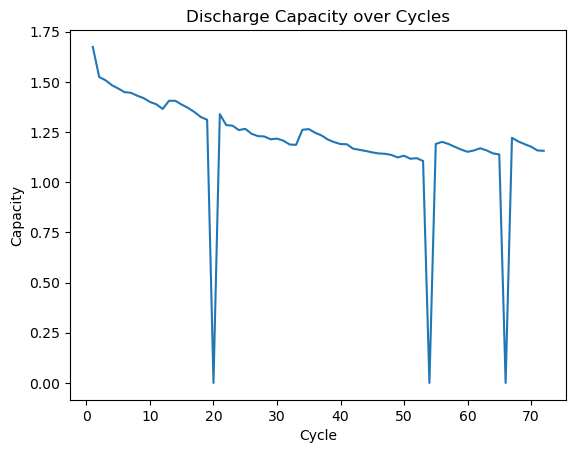

In [9]:
import matplotlib.pyplot as plt
plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.title('Discharge Capacity over Cycles')
plt.plot(new_df['cycle'], new_df['Capacity'])
plt.show()

In [10]:
discharge_meta = metadata[metadata["type"] == "discharge"].copy()

discharge_meta["Capacity_num"] = pd.to_numeric(
    discharge_meta["Capacity"],
    errors="coerce"
)

discharge_meta[discharge_meta["Capacity_num"].isna()][
    ["battery_id", "test_id", "filename", "Capacity"]
]

,battery_id,test_id,filename,Capacity
4370,B0050,52,04371.csv,[]
4372,B0050,54,04373.csv,[]
4374,B0050,56,04375.csv,[]
4376,B0050,58,04377.csv,[]
4390,B0052,10,04391.csv,[]
4394,B0052,14,04395.csv,[]
4396,B0052,16,04397.csv,[]
4398,B0052,18,04399.csv,[]
4400,B0052,20,04401.csv,[]
4402,B0052,22,04403.csv,[]


In [11]:
err = metadata[(metadata["type"] == "discharge") & (metadata['battery_id'] == "B0050")].copy()
err.head(5)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
4318,discharge,[2010. 8. 23. 17. 51. ...,4,B0050,0,4319,04319.csv,0.8631448527758341,NaN,NaN
4322,discharge,[2010. 8. 23. 22. 33. ...,4,B0050,4,4323,04323.csv,1.648789607776492,NaN,NaN
4324,discharge,[2.0100e+03 8.0000e+00 2.4000e+01 2.0000e+00 2...,4,B0050,6,4325,04325.csv,1.601636485397804,NaN,NaN
4326,discharge,[2010. 8. 24. 6. 23. ...,4,B0050,8,4327,04327.csv,1.5517564797427017,NaN,NaN
4328,discharge,[2010. 8. 26. 11. 4. ...,4,B0050,10,4329,04329.csv,0.03255841710834194,NaN,NaN


In [12]:
err[err['Capacity'] == "[]"].head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
4370,discharge,[2010. 8. 29. 7. 9. ...,4,B0050,52,4371,04371.csv,[],NaN,NaN
4372,discharge,[2010. 8. 29. 10. 39. ...,4,B0050,54,4373,04373.csv,[],NaN,NaN
4374,discharge,[2010. 8. 29. 14. 11. ...,4,B0050,56,4375,04375.csv,[],NaN,NaN
4376,discharge,[2010. 8. 29. 17. 40. ...,4,B0050,58,4377,04377.csv,[],NaN,NaN


In [13]:
df = pd.read_csv("cleaned_dataset/data/04371.csv")
df2 = pd.read_csv("cleaned_dataset/data/04373.csv")

In [14]:
df.tail(5)

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
149,3.817861,-0.001233,5.136458,0.0004,0.0,1590.062
150,3.818035,-0.003153,5.175501,0.0004,0.0,1600.890
151,3.817993,-0.002356,5.221796,0.0004,0.0,1611.672
152,3.818088,-0.004244,5.244941,0.0004,0.0,1622.437
153,3.817983,-0.002337,5.276915,0.0004,0.0,1633.250


In [15]:
df2.tail(5)

,Voltage_measured,Current_measured,Temperature_measured,Current_load,Voltage_load,Time
158,0.270870,-0.000356,6.382631,0.0004,0.0,1693.843
159,0.270589,-0.001332,6.390985,0.0004,0.0,1704.734
160,0.269908,-0.000578,6.396816,0.0004,0.0,1715.500
161,0.270129,-0.000545,6.403584,0.0004,0.0,1726.390
162,0.270913,-0.000122,6.412030,0.0004,0.0,1737.172


In [16]:
metadata[(metadata['type'] == 'discharge') & (metadata['battery_id'] == 'B0033')].head(5)

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
2412,discharge,[2009. 6. 19. 17. 18. ...,24,B0033,0,2413,02413.csv,0.06842572240601812,NaN,NaN
2416,discharge,[2.0090e+03 6.0000e+00 1.9000e+01 2.2000e+01 2...,24,B0033,4,2417,02417.csv,0.6895699007862814,NaN,NaN
2418,discharge,[2.009e+03 6.000e+00 2.000e+01 1.000e+00 5.900...,24,B0033,6,2419,02419.csv,1.1610848192311252,NaN,NaN
2420,discharge,[2009. 6. 20. 5. 55. ...,24,B0033,8,2421,02421.csv,1.2529393053824995,NaN,NaN
2422,discharge,[2009. 6. 20. 9. 50. ...,24,B0033,10,2423,02423.csv,1.302918002447558,NaN,NaN


In [17]:
discharge_meta.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,Capacity_num
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN,1.674305
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN,1.524366
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.5080762969973425,NaN,NaN,1.508076
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.4835577960067696,NaN,NaN,1.483558
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.4671391666146525,NaN,NaN,1.467139


In [18]:
discharge_meta['battery_id'].value_counts()

battery_id
B0033    197
B0036    197
B0034    197
B0007    168
B0005    168
B0006    168
B0018    132
B0044    112
B0043    112
B0042    112
B0054    103
B0056    102
B0055    102
B0047     72
B0048     72
B0045     72
B0046     72
B0041     67
B0053     56
B0040     47
B0039     47
B0038     47
B0030     40
B0029     40
B0031     40
B0032     40
B0026     28
B0025     28
B0028     28
B0027     28
B0049     25
B0052     25
B0051     25
B0050     25
Name: count, dtype: int64

In [19]:
discharge_meta["Capacity"] = pd.to_numeric(discharge_meta["Capacity"], errors="coerce")

initial_capacity = discharge_meta.groupby("battery_id")["Capacity"].transform("first")

discharge_meta["SOH"] = (discharge_meta["Capacity"] / initial_capacity)*100

In [20]:
discharge_meta.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,Capacity_num,SOH
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN,1.674305,100.000000
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN,1.524366,91.044729
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,NaN,NaN,1.508076,90.071793
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,NaN,NaN,1.483558,88.607394
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,NaN,NaN,1.467139,87.626770


In [21]:
discharge_clean = discharge_meta[discharge_meta["Capacity"] != "[]"].copy()

In [22]:
discharge_clean.shape

(2794, 12)

In [23]:
discharge_clean.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,Capacity_num,SOH
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN,1.674305,100.000000
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN,1.524366,91.044729
6,discharge,[2.010e+03 7.000e+00 2.200e+01 1.000e+00 4.000...,4,B0047,6,7,00007.csv,1.508076,NaN,NaN,1.508076,90.071793
8,discharge,[2010. 7. 22. 6. 16. ...,4,B0047,8,9,00009.csv,1.483558,NaN,NaN,1.483558,88.607394
10,discharge,[2010. 7. 22. 10. 51. ...,4,B0047,10,11,00011.csv,1.467139,NaN,NaN,1.467139,87.626770


In [24]:
discharge_clean["Capacity"].astype(float)

0       1.674305
4       1.524366
6       1.508076
8       1.483558
10      1.467139
          ...   
7553    1.028527
7555    0.981684
7557    1.012712
7561    1.020138
7563    0.990759
Name: Capacity, Length: 2794, dtype: float64

In [25]:
discharge_clean.drop(
    discharge_clean[discharge_clean["Capacity"] == 0].index,
    inplace=True
)

In [27]:
discharge_clean["discharge_index"] = (
    discharge_clean.groupby("battery_id").cumcount() + 1
)

discharge_clean["reference_capacity"] = (
    discharge_clean.groupby("battery_id")["Capacity"]
    .transform(lambda x: x.iloc[1])
)

discharge_clean["SOH"] = (
    discharge_clean["Capacity"]
    / discharge_clean["reference_capacity"] * 100
)

discharge_clean = discharge_clean[
    discharge_clean["discharge_index"] >= 2
].copy()

discharge_clean["SOH_change"] = (
    discharge_clean.groupby("battery_id")["SOH"].diff()
)

discharge_clean["spike_candidate"] = (
    discharge_clean["SOH_change"] > 1
)

In [31]:
discharge_clean["SOH_abs_change"] = (
    discharge_clean.groupby("battery_id")["SOH"]
    .diff()
    .abs()
)

discharge_clean["SOH_abs_change"] 

4            NaN
6       1.068635
8       1.608439
10      1.077079
12      1.199253
          ...   
7553    1.884382
7555    3.548967
7557    2.350776
7561    0.562611
7563    2.225851
Name: SOH_abs_change, Length: 2741, dtype: float64

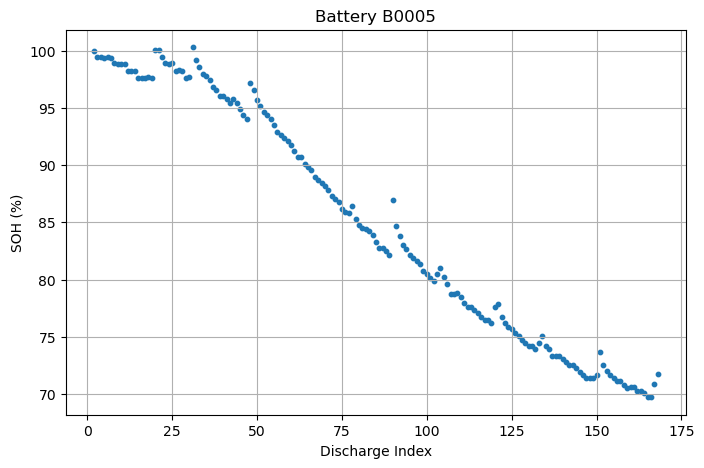

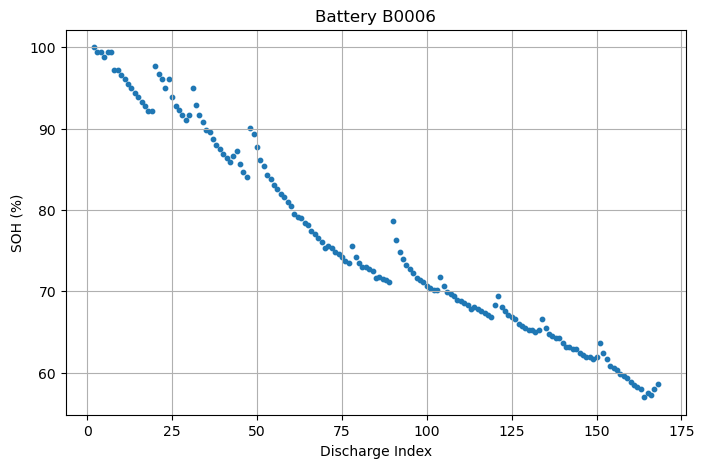

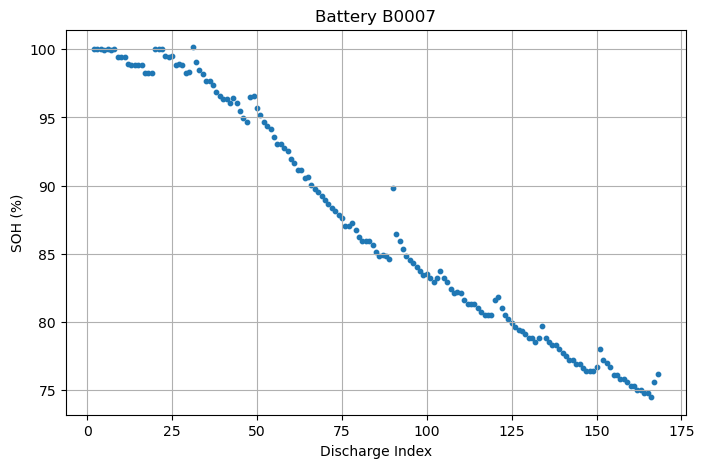

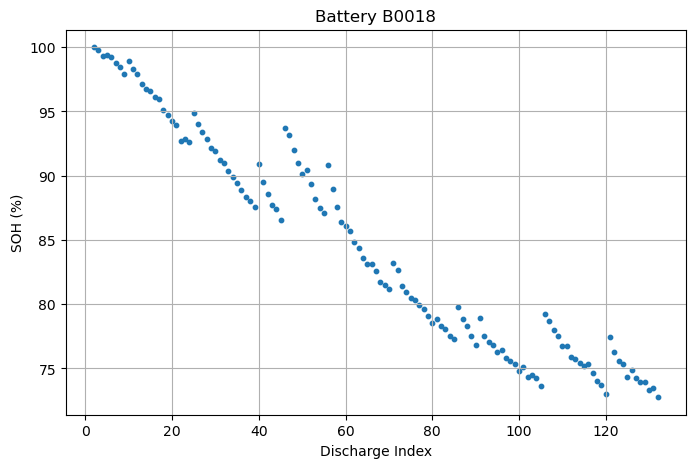

In [33]:
for battery_id, group in discharge_clean.groupby("battery_id"):
    if int(battery_id[1:]) > 20:
        break

    plt.figure(figsize=(8, 5))
    plt.scatter(group["discharge_index"], group["SOH"], s=10)
    plt.title(f"Battery {battery_id}")
    plt.xlabel("Discharge Index")
    plt.ylabel("SOH (%)")
    plt.grid(True)
    plt.show()